# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks')
import functions  # First import
import importlib
importlib.reload(functions)  # Reload to reflect changes
from functions import *  # Now import updated functions

#add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

# Read data

In [ ]:
np.random.seed(1002)
random.seed(0)

total_filter = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co.pkl')
ALL = total_filter.copy(deep = True)
ALL = ALL[(ALL['CO content in the raw gas (preheater outlet)'] > 0) & (ALL['CO content in the raw gas (preheater outlet)'] < 800)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO content in the raw gas (preheater outlet)']]

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

# All model training (CO)

### SVR works best

In [3]:
titles = ['Linear regression', 'Lasso', 'Ridge', 'Elastic net', 'Random forest', 'XGBoost', 'SVR', 'GPR', 'NN']

In [4]:
train_scores = []
val_scores = []
test_scores = []

# LR

LinearRegression()

Avg Training:  R^2 = 0.85, MAE = 36.49, MAPE = 16.08%
Avg Val:  R^2 = 0.85, MAE = 36.52, MAPE = 16.1%
Test 0.85 36.17 15.98


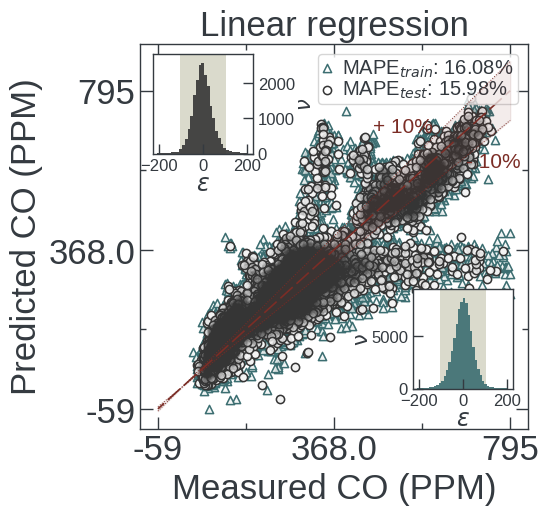

In [11]:
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)

avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Lasso

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.062e+07, tolerance: 1.050e+05


[CV] END ........................................alpha=1e-05; total time=   2.6s


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.956e+07, tolerance: 1.050e+05


[CV] END .......................................alpha=0.0001; total time=   3.0s


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.852e+07, tolerance: 1.050e+05


[CV] END ........................................alpha=0.001; total time=   3.1s
[CV] END ..........................................alpha=0.1; total time=   1.9s
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 14.4206 s
System CPU time  : 0.1091 s
Total CPU time   : 14.5298 s
Wall clock time  : 14.5861 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.51%
Max CPU usage    : 1.61%
Logical cores    : 64
Physical cores   : 32


{'alpha': 0.1}

Avg Training:  R^2 = 0.85, MAE = 36.46, MAPE = 16.07%
Avg Val:  R^2 = 0.85, MAE = 36.48, MAPE = 16.08%
Test 0.85 36.14 15.96


X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names


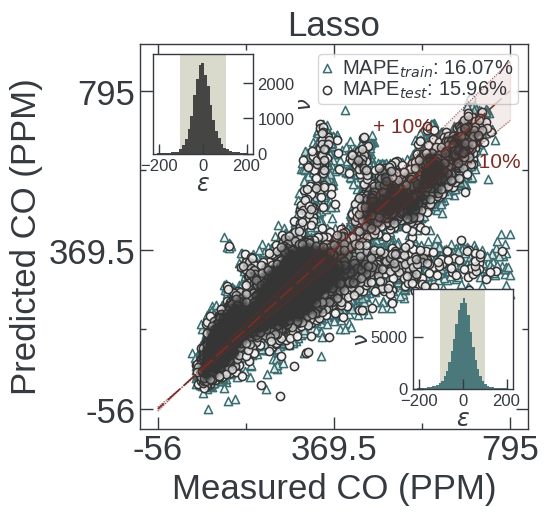

In [12]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Lasso()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
end_profiling(save_path = None, note = None)
random_search.best_params_
# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[1]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[1],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Ridge

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 0.1}

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.1848 s
System CPU time  : 0.0281 s
Total CPU time   : 0.2129 s
Wall clock time  : 0.5618 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.85, MAE = 36.49, MAPE = 16.08%
Avg Val:  R^2 = 0.85, MAE = 36.52, MAPE = 16.1%


X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names


Test 0.85 36.17 15.98


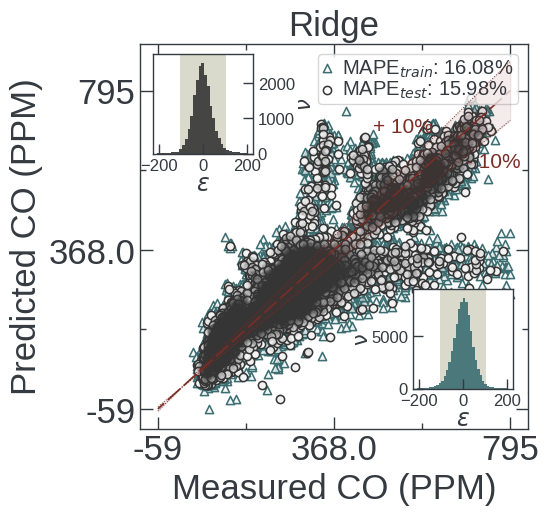

In [13]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Ridge()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[2]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[2],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Elastic net

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.068e+07, tolerance: 1.050e+05


[CV] END ........................................alpha=1e-05; total time=   2.8s


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.018e+07, tolerance: 1.050e+05


[CV] END .......................................alpha=0.0001; total time=   2.5s


...

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.001e+08, tolerance: 1.405e+05


{'alpha': 0.001}

GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 15 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 15.4124 s
System CPU time  : 0.1079 s
Total CPU time   : 15.5203 s
Wall clock time  : 15.5852 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.51%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.523e+07, tolerance: 1.055e+05
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.387e+07, tolerance: 1.053e+05
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.580e+07, tolerance: 1.054e+05
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.534e+07, tolerance: 1.052e+05
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names


Avg Training:  R^2 = 0.85, MAE = 36.47, MAPE = 16.07%
Avg Val:  R^2 = 0.85, MAE = 36.5, MAPE = 16.08%
Test 0.85 36.15 15.97


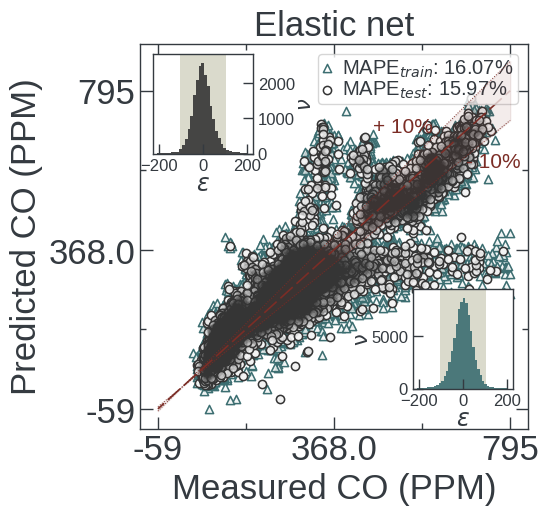

In [14]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = ElasticNet()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
iterations = 4
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[3]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[3],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Random forest

{'n_estimators': 600,
 'min_samples_split': 16,
 'min_samples_leaf': 16,
 'max_features': 0.4,
 'max_depth': 25,
 'ccp_alpha': 0.0,
 'bootstrap': True}

GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB
---- NOTE ----
RandomSearchCV for plant 1 Rf co

---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 899.6402 s
System CPU time  : 4.9052 s
Total CPU time   : 904.5454 s
Wall clock time  : 257.4219 s

---- CPU Utilization Stats ----
Avg CPU usage    : 20.61%
Max CPU usage    : 98.77%
Logical cores    : 64
Physical cores   : 32


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.98, MAE = 10.3, MAPE = 4.1%
Avg Val:  R^2 = 0.97, MAE = 12.42, MAPE = 4.96%
Test 0.97 12.48 5.0


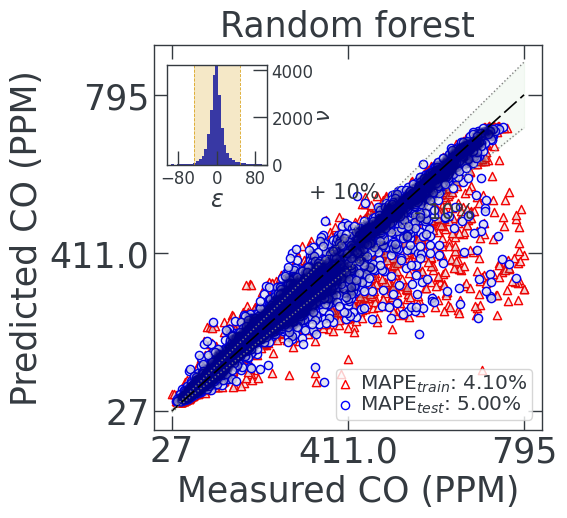

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
hyperparameter_grid = {
    "n_estimators": [ 600, 800],
    "max_depth": [24, 25],        # None = grow until pure
    "min_samples_split": [16],
    "min_samples_leaf": [ 16],
    "max_features": [0.4],
    "ccp_alpha": [0.0],
    "bootstrap": [True]
}
iterations =100
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, np.ravel(y_train), # ravel for randomforest
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant1/RF_CO_RanSearchCV.txt',
              note = 'RandomSearchCV for plant 1 Rf co')
save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_co_best.pkl')

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant1/co_RF.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[4]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[4],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

In [ ]:
best_rf = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_co_best.pkl')
best_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 25,
 'max_features': 0.4,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 16,
 'min_samples_split': 16,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 600,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.98, MAE = 10.3, MAPE = 4.1%
Avg Val:  R^2 = 0.97, MAE = 12.42, MAPE = 4.96%


X has feature names, but RandomForestRegressor was fitted without feature names
X has feature names, but RandomForestRegressor was fitted without feature names
X has feature names, but RandomForestRegressor was fitted without feature names


Test 0.97 11.75 4.68


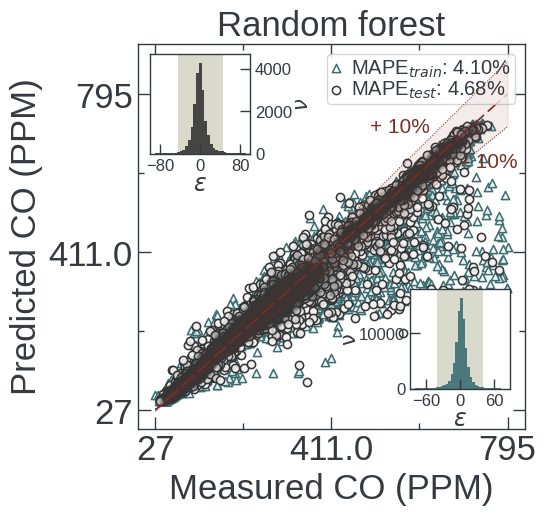

In [ ]:
# best model overfit, this model is more genralizable model better
np.random.seed(1002)
random.seed(0)
# best_regressor = RandomForestRegressor(n_estimators  = 1000,  min_samples_split  = 4,  min_samples_leaf  = 8, 
#                                   max_features  = 0.6,  max_depth  = 24,  ccp_alpha  = 0.001, 
#                                   bootstrap  = True, random_state=42, n_jobs=-1)
best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_co_best.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# XGboost

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1)
# hyperparameter_grid = {
#     "n_estimators": [200, 400, 600, 800],            # more trees but slower learning
#     "max_depth": [3, 4, 5, 6, 7],                   # shallower trees → less overfitting
#     "min_child_weight": [5, 7, 9, 11],               # larger = less complex splits
#     "subsample": [0.6, 0.7, 0.8, 0.9],               # row sampling
#     "colsample_bytree": [0.6, 0.7, 0.8, 0.9],        # feature sampling
#     "learning_rate": [0.01, 0.02, 0.03, 0.05],       # slower learning → needs more trees
#     "reg_lambda": [5, 7, 9, 11],                     # L2 regularization
#     "reg_alpha": [3, 5, 7, 9]                        # L1 regularization
# }
# iterations =100
# best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
#                                                        iterations = iterations, verbose= 2)
# random_search.best_params_
# end_profiling(save_path = None, note = None)

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = 'palnt2 CO XGBoost',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/XGboost.txt')
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[5],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

Avg Training:  R^2 = 1.0, MAE = 2.81, MAPE = 1.27%
Avg Val:  R^2 = 0.98, MAE = 9.88, MAPE = 3.88%
Test 0.98 9.39 3.7


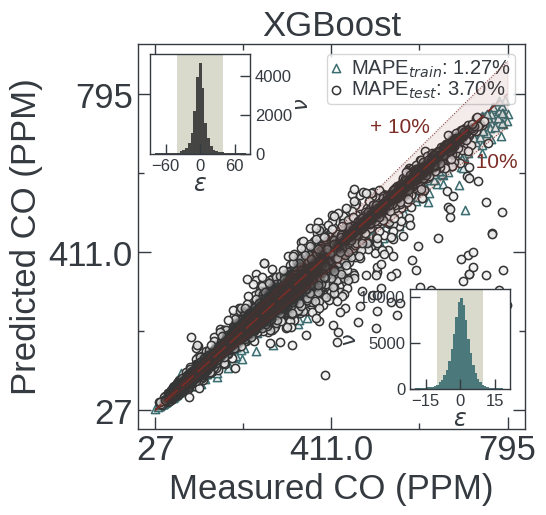

In [12]:
# manually tuned model
np.random.seed(1002)
random.seed(0)
best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co/plant_1_co.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Best model stats

In [7]:
np.random.seed(1002)
random.seed(0)

start_profiling() 

model_nox = XGBRegressor(
subsample = 0.7,  # reduce for generalizaiton
reg_lambda = 1,  # 
reg_alpha = 1,  # 
n_estimators = 1600,  # 
min_child_weight = 7,  # increase for generalizaiton
max_depth = 11,  #  
learning_rate = 0.020,  # Lowered for more stable updates  
colsample_bytree = 0.8,  # reduce for generalizaiton
random_state = 42,  
tree_method = 'gpu_hist',  
n_jobs = -1  

).fit(X_train,y_train)
train_test_score(model_nox, X_train, X_test, y_train, y_test)

end_profiling()

model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co/plant_1_co.pkl')

GPU 0: Utilization: 0%, Memory Used: 525 MB / 12282 MB
Training 1.0 3.34 1.49
Test 0.98 9.44 3.72
GPU 0: Utilization: 0%, Memory Used: 559 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 525 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 559 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 45.5625 s
System CPU time  : 0.2908 s
Total CPU time   : 45.8532 s
Wall clock time  : 46.1624 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.55%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Model size: 45.56 MB


# SVR

In [ ]:
# np.random.seed(1002)
# random.seed(0)
# start_profiling() 

# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= SVR(),
#         transformer=StandardScaler()))
# ])
# hyperparameter_grid = {
#     "kernel":  ["rbf", "poly", "sigmoid"],
#     "C":       [0.1, 1, 10, 50, 100, 200, 500],
#     "epsilon": [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
#     "gamma":   ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1],
#     "degree":  [2, 3, 4],          
#     "coef0":   [0.0, 0.1, 0.5, 1.0],
#     "tol":     [1e-4, 1e-3, 1e-2],
#     "shrinking": [True, False]
# }

# iterations = 200
# best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
#                                                        iterations = iterations, verbose= 1)
# random_search.best_params_
# end_profiling(save_path = None,
#               note = 'RandomSearchCV for plant 4 SVR')

# # save_model(best_regressor,
# #            model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/svr_best.pkl') # =None if not want to save

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/svr.txt")
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[6],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

In [ ]:
# # Iteration 40
# regressor = SVR(tol= 0.0001, shrinking= False, kernel= 'rbf', gamma= 0.001, epsilon= 0.2, degree= 3, coef0= 0.5, C= 50)
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= regressor,
#         transformer=StandardScaler()))
# ])
# pipeline.fit(X_train, y_train)
# avg_train_results, _ = k_fold_scores(pipeline, X_train, y_train)
# test_results = parity_train_test(pipeline, titles[6],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

# GPR

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= GaussianProcessRegressor(random_state=3),
#         transformer=StandardScaler()))
# ])
# hyperparameter_grid = {
#     "kernel": (
#         # Matern + WhiteKernel
#         [
#             ConstantKernel(1.0, (1e-3, 1e3)) *
#             Matern(length_scale=ls, nu=nu) +
#             WhiteKernel(noise_level=noise)
#             for ls in [0.1, 0.5, 1, 2, 5, 10]
#             for nu in [0.5, 1.5, 2.5]
#             for noise in [1e-5, 1e-3, 1e-1, 1]
#         ]
#         +
#         # RBF + WhiteKernel
#         [
#             ConstantKernel(1.0, (1e-3, 1e3)) *
#             RBF(length_scale=ls) +
#             WhiteKernel(noise_level=noise)
#             for ls in [0.1, 0.5, 1, 2, 5, 10]
#             for noise in [1e-5, 1e-3, 1e-1, 1]
#         ]
#         +
#         # RationalQuadratic + WhiteKernel
#         [
#             ConstantKernel(1.0, (1e-3, 1e3)) *
#             RationalQuadratic(length_scale=ls, alpha=alpha) +
#             WhiteKernel(noise_level=noise)
#             for ls in [0.1, 0.5, 1, 2, 5, 10]
#             for alpha in [0.1, 0.5, 1, 2]
#             for noise in [1e-5, 1e-3, 1e-1, 1]
#         ]
#     ),
#     "alpha": [1e-10, 1e-5, 1e-3, 1e-2, 1e-1, 1],
#     "normalize_y": [True, False],
# }

# iterations =200
# best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
#                                                        iterations = iterations, verbose= 1)
# random_search.best_params_
# end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant2/gpr_rand_SearchCV.txt',
#               note = 'RandomSearchCV for plant 2 gpr')

# save_model(best_regressor,
#            model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/gpr_best.pkl')

# # save Randomsearch results
# log_search_space(random_search.cv_results_ , file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/gpr.txt")
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[7],'CO (PPM)', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

In [ ]:
# # Iteration 
# np.random.seed(1002)
# random.seed(0)

# regressor = GaussianProcessRegressor(random_state = 3,
# normalize_y= True, kernel=1**2 * RationalQuadratic(alpha=2, length_scale=5) + WhiteKernel(noise_level=0.1), alpha = 1)
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= regressor,
#         transformer=StandardScaler()))
# ])
# pipeline.fit(X_train, y_train)
# avg_train_results, _ = k_fold_scores(pipeline, X_train, y_train)
# test_results = parity_train_test(pipeline, titles[7],'CO (PPM)', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

# NN

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= MLPRegressor(),
#         transformer=StandardScaler()))
# ])
# hyperparameter_grid = {
#     'hidden_layer_sizes': [
#         (64,), (128,), (256,),          # Single layer
#         (64, 32), (128, 64), (256, 128), # Two layers
#         (128, 64, 32), (64, 32, 16)      # Three layers (only for more data)
#     ],
#     'activation': ['relu'],
#     'learning_rate_init': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
#     'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
#     'batch_size': [16, 32, 64, 128],
#     'solver': ['adam'],  # 'lbfgs' works better for small datasets, 'adam' for large
#     'early_stopping': [True],  # Keep fixed if you're using validation
#     'n_iter_no_change': [20],
#     'validation_fraction': [0.2],
#     'max_iter': [500],
#     'random_state': [42], 
#     'verbose': [False]
# }
# iterations =150
# best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train,  # ravel for NN
#                                                        iterations = iterations, verbose= 1)

# random_search.best_params_
# end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant1/NN_co_rand_SearchCV.txt',
#               note = 'RandomSearchCV for plant 1 co nn')
# save_model(best_regressor,
#            model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_co_best.pkl')

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant1/co_nn.txt")
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[8],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

Avg Training:  R^2 = 0.98, MAE = 12.13, MAPE = 4.98%
Avg Val:  R^2 = 0.97, MAE = 13.11, MAPE = 5.3%
Test 0.98 12.57 5.11


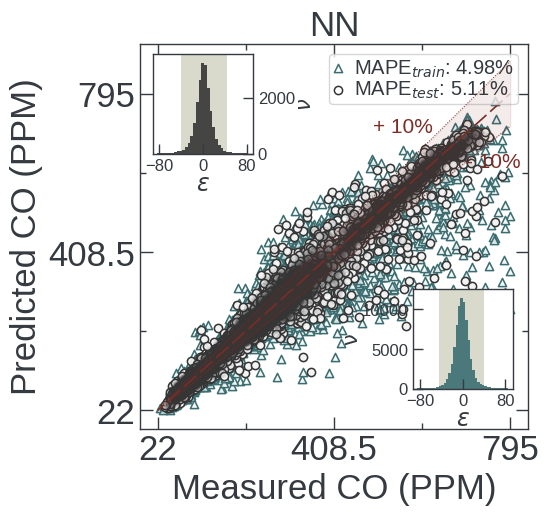

In [ ]:
# best model params:
# regressor = MLPRegressor(
# early_stopping = True ,             
# n_iter_no_change = 20,
# random_state = 42,
# activation = 'relu',                  
# solver = 'adam',                    
# max_iter = 500, 
# verbose = True,
 
# hidden_layer_sizes = (256, 128, 64),  
# learning_rate_init = 0.003 ,          
# batch_size = 64,                    
# alpha = 0.0005 
np.random.seed(1002)
random.seed(0)
best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_co_best.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[8]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[8],'CO (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Radar plots for trian/val/test

In [4]:
train_sc = [(0.85, 36.49, 16.08),
 (0.85, 36.46, 16.07),
 (0.85, 36.49, 16.08),
 (0.85, 36.47, 16.07),
 (0.98, 10.3, 4.1),
 (1.0, 2.89, 1.3),
(np.NaN,np.NaN,np.NaN), 
(np.NaN,np.NaN,np.NaN),
 (0.98, 12.13, 4.98)]

val_sc = [(0.85, 36.52, 16.1),
 (0.85, 36.48, 16.08),
 (0.85, 36.52, 16.1),
 (0.85, 36.5, 16.08),
 (0.97, 12.42, 4.96),
 (0.98, 9.92, 3.88),
(np.NaN,np.NaN,np.NaN), 
(np.NaN,np.NaN,np.NaN),
 (0.97, 13.11, 5.3)]
 
test_sc = [(0.85, 36.17, 15.98),
 (0.85, 36.14, 15.96),
 (0.85, 36.17, 15.98),
 (0.85, 36.15, 15.97),
 (0.97, 11.75, 4.68),
 (0.99, 4.45, 1.9),
(np.NaN,np.NaN,np.NaN), 
(np.NaN,np.NaN,np.NaN),
 (0.98, 12.57, 5.11)]
 
# with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_train_co.pkl", "wb") as f:  
#     pickle.dump(train_sc, f)
    
# with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_val_co.pkl", "wb") as f:  
#     pickle.dump(val_sc, f)
    
# with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_test_co.pkl", "wb") as f:  
#     pickle.dump(test_sc, f)
 

LinearRegression()

Test 0.85 36.17 15.98


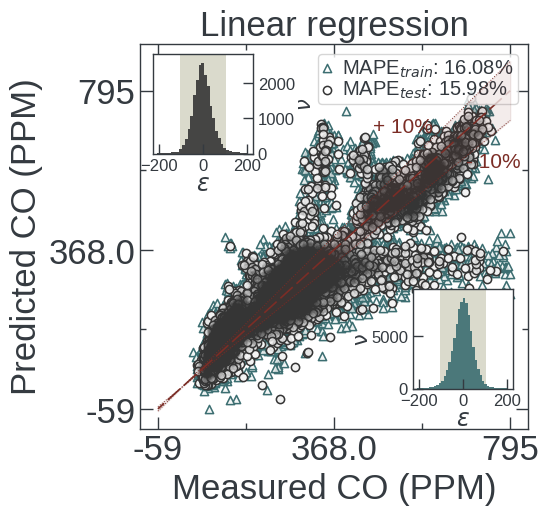

Lasso(alpha=0.01)

Test 0.85 36.17 15.98


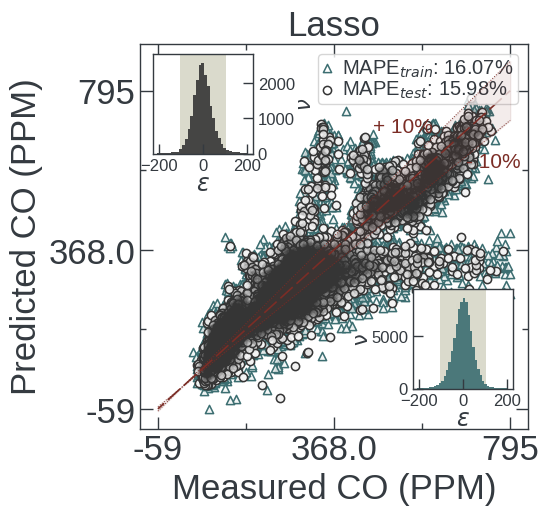

Ridge(alpha=0.1)

Test 0.85 36.17 15.98


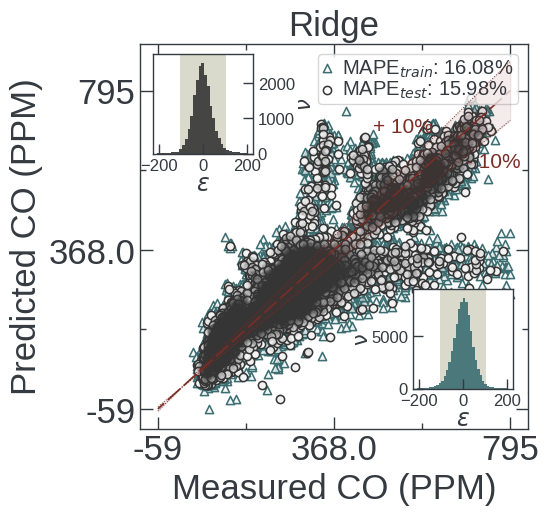

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.001e+08, tolerance: 1.405e+05


ElasticNet(alpha=0.001)

Test 0.85 36.15 15.97


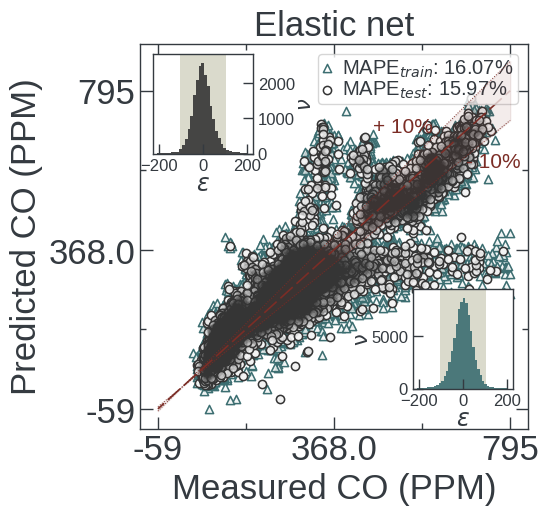

X has feature names, but RandomForestRegressor was fitted without feature names
X has feature names, but RandomForestRegressor was fitted without feature names
X has feature names, but RandomForestRegressor was fitted without feature names


Test 0.97 11.75 4.68


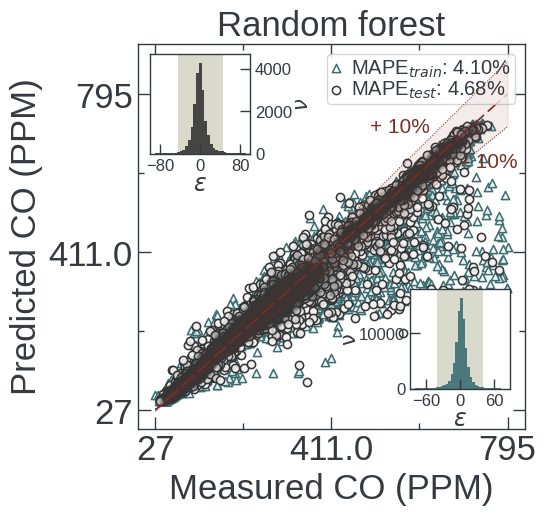

[22:46:40] WARNING: ../src/gbm/gbtree.cc:415: 
  Loading from a raw memory buffer (like pickle in Python, RDS in R) on a CPU-only
  machine. Consider using `save_model/load_model` instead. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.  Changing `tree_method` to `hist`.
[22:46:40] WARNING: ../src/gbm/gbtree.cc:425: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
[22:46:40] WARNING: ../src/learner.cc:339: No visible GPU is found, setting `gpu_id` to -1
Test 0.99 4.45 1.9


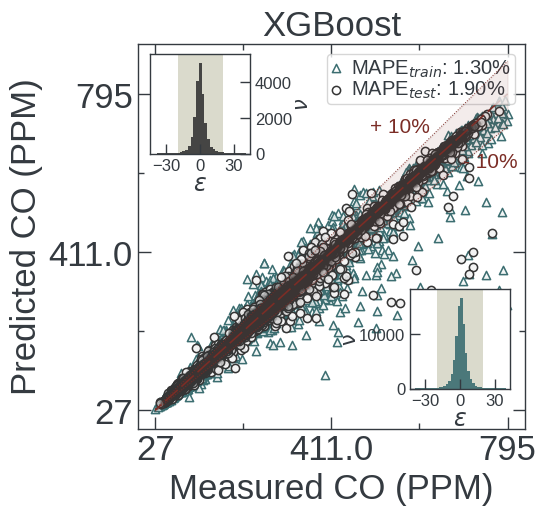

Test 0.98 12.57 5.11


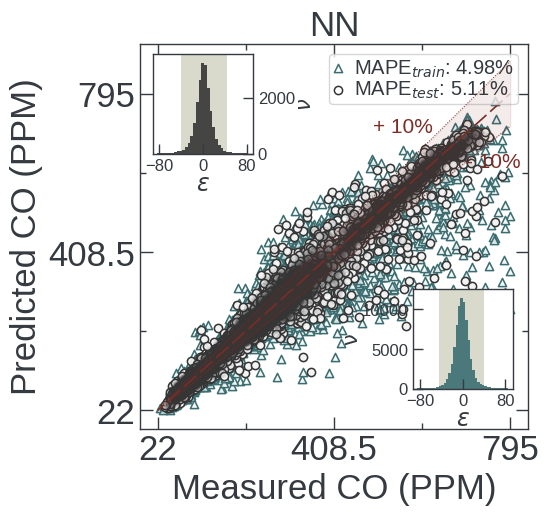

In [6]:
np.random.seed(1002)
random.seed(0)
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'CO (PPM)', X_train, X_test, y_train,y_test, list(train_sc[0]), y, fig_path = fig_path)


best_regressor = Lasso(alpha = 0.01)
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[1]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[1],'CO (PPM)', X_train, X_test, y_train, y_test,list(train_sc[1]), y, fig_path = fig_path)

best_regressor = Ridge(alpha = 0.1)
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[2]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[2],'CO (PPM)', X_train, X_test, y_train, y_test,list(train_sc[2]), y, fig_path = fig_path)

best_regressor = ElasticNet(alpha = 0.001)
best_regressor.fit(X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[3]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[3],'CO (PPM)', X_train, X_test, y_train, y_test,list(train_sc[3]), y, fig_path = fig_path)

best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_co_best.pkl')
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'CO (PPM)', X_train, X_test, y_train, y_test,list(train_sc[4]), y, fig_path = fig_path)

best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co/plant_1_co.pkl')
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'CO (PPM)', X_train, X_test, y_train, y_test,list(train_sc[5]), y, fig_path = fig_path)

best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_co_best.pkl')
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co/{titles[8]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[8],'CO (PPM)', X_train, X_test, y_train, y_test,list(train_sc[8]), y, fig_path = fig_path)